In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import  pyplot as plt 

In [2]:
from xaikd import constants

In [3]:
base_dir = f"../../artifacts/2024-03-s23/experiments/accuracy-curves/1-all-models"

In [5]:
def read_data(dataset, model, layer, logit_mod, basis_name, gamma):
    model = model
    layer = layer
    df = pd.read_csv(
        f"{base_dir}/{dataset}/{model}/{logit_mod}/{layer}/{basis_name}--gamma{gamma}.csv"
    )
    return df

read_data(
    dataset="imagenet-butterfly",
    model="imagenet-vgg16-tv",
    layer="features.16",
    logit_mod="winninglogit",
    basis_name="prcaopt",
    gamma=0.25
)

,layer,k,acc,ref_acc
0,features.16,2,0.473333,0.96
1,features.16,4,0.740000,0.96
2,features.16,6,0.823333,0.96
3,features.16,8,0.853333,0.96
4,features.16,10,0.873333,0.96
5,features.16,12,0.903333,0.96
6,features.16,14,0.913333,0.96
7,features.16,16,0.926667,0.96
8,features.16,18,0.923333,0.96
9,features.16,20,0.926667,0.96


In [6]:
import re
def find_ratios(names):
    
    arr = []
    
    for t in names:
        m = re.match(r"pca([\.\d]+)prcasortabs", t)
        if m:
            arr.append(float(m.group(1)))
            
    
    return arr

find_ratios([
        "pca",
        "prcasortabs",
        "pca0.1prcasortabs",
        "pca0.25prcasortabs",
        "pca0.5prcasortabs",
        "pca1.0prcasortabs",
    ])

[0.1, 0.25, 0.5, 1.0]

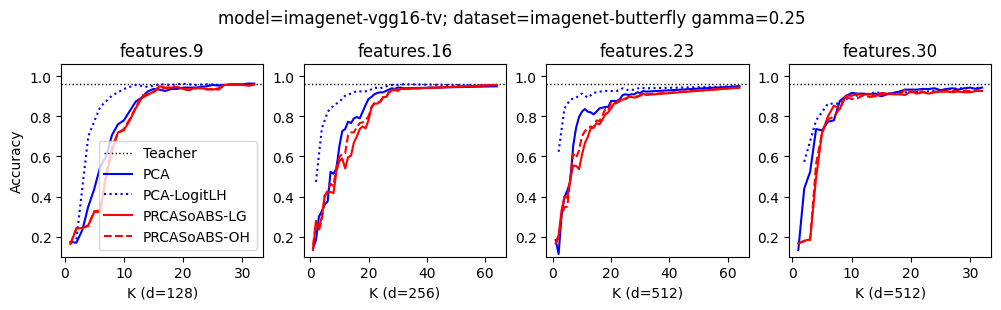

In [50]:
def alias(name, logit_mod):
    if "pca" in name:
        return "PCA"
    elif name == "prcaopt":
        return "PCA-LogitLH"
    elif name == "prcasortabs":
        if logit_mod == "winningonehot":
            return f"PRCASoABS-OH"
        elif logit_mod == "winninglogit":
            return f"PRCASoABS-LG"
        else:
            raise
    else:
        raise

def ls(name, logit_mod):
    if name == "pca":
        return "-"
    elif name == "prcaopt":
        return ":"
    elif name == "prcasortabs":
        if logit_mod == "winninglogit":
            return "-"
        else:
            return "--"
    
def viz(
    dataset,
    model,
    gamma=0.25,
    arr_basis_names=[
       "pca:winninglogit",
        "prcaopt:winninglogit",
       "prcasortabs:winninglogit",
       "prcasortabs:winningonehot", 
    ],
    arr_max_k=[32, 64, 64, 32],
):    
    _, arch, _ = model.split("-")

    arr_layers = list(constants.ARCH_LAYER_DIMENSIONS[arch].keys())

    ncols = len(arr_layers)

    plt.figure(figsize=(3*ncols, 2.5))
    
    plt.suptitle(f"model={model}; dataset={dataset} gamma={gamma}", y=1.1)

    
    arr_ratios = np.array(find_ratios(arr_basis_names))
    color_index = np.linspace(0.25, 1, len(arr_ratios))
    cmap_reds = mpl.colormaps.get_cmap("Reds")

    def color(name):
        if name == "pca" or name == "prcaopt":
            return "blue"
        elif "prca" in name:
            return "red"
        
#         elif re.match(r"pca([\.\d]+)prcasortabs", name):
#             ratio = float(re.match(r"pca([\.\d]+)prcasortabs", name).group(1))

#             ix = np.argwhere(arr_ratios == ratio).reshape(-1)[0]
#             return cmap_reds(color_index[ix])
#             return mpl.colormaps.get_cmap("Reds")(ratio + 0.1)
        else:
            raise
        
    for lix, (layer, max_k) in enumerate(zip(arr_layers, arr_max_k)):
        plt.subplot(1, ncols, lix +1)
        
        plt.title(layer)
        
        for bix, basis_name_logit_mod in enumerate(arr_basis_names):
            basis_name, logit_mod = basis_name_logit_mod.split(":")
            df = read_data(
                dataset=dataset,
                model=model,
                layer=layer,
                basis_name=basis_name,
                logit_mod=logit_mod,
                gamma=gamma,
            )
            dims = df.k.max()

            if bix == 0:
                ref_acc = df.ref_acc.values[0]
                plt.axhline(
                    ref_acc, ls=":", label="Teacher", 
                    color="k",
                    lw=1
                )
                plt.ylim([0.1, ref_acc+0.1])
            
            _df = df[df.k <= max_k]
            plt.plot(
                _df.k,
                _df.acc,
                ls=ls(basis_name, logit_mod),
#                 marker=".",
                color=color(basis_name),
                label=alias(basis_name, logit_mod)
            )
                

            plt.xlabel(f"K (d={dims})")
                
        if lix == 0:
            plt.ylabel("Accuracy")
        
        if lix == 0:
            plt.legend()
viz(
    dataset="imagenet-butterfly",
    model="imagenet-vgg16-tv",
    arr_max_k=[32, 64, 64, 32],
)

In [51]:
arr_archs = """
imagenet-vgg11-tv
imagenet-vgg11bn-tv
imagenet-vgg13-tv
imagenet-vgg13bn-tv
imagenet-vgg16-tv
imagenet-vgg16bn-tv
imagenet-vgg19-tv
imagenet-vgg19bn-tv
imagenet-resnet18-tv
imagenet-resnet34-tv
imagenet-resnet101-tv
imagenet-resnet152-tv
""".strip().split("\n")
arr_archs

['imagenet-vgg11-tv',
 'imagenet-vgg11bn-tv',
 'imagenet-vgg13-tv',
 'imagenet-vgg13bn-tv',
 'imagenet-vgg16-tv',
 'imagenet-vgg16bn-tv',
 'imagenet-vgg19-tv',
 'imagenet-vgg19bn-tv',
 'imagenet-resnet18-tv',
 'imagenet-resnet34-tv',
 'imagenet-resnet101-tv',
 'imagenet-resnet152-tv']

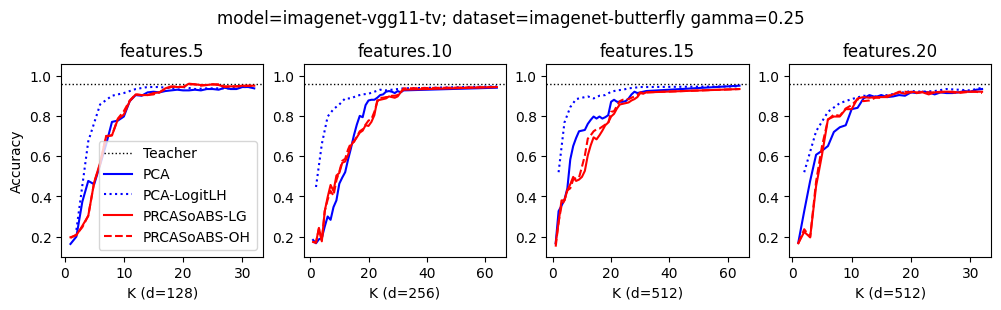

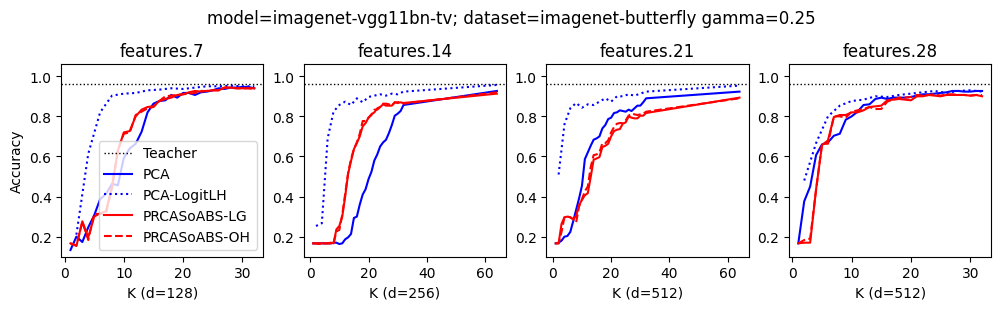

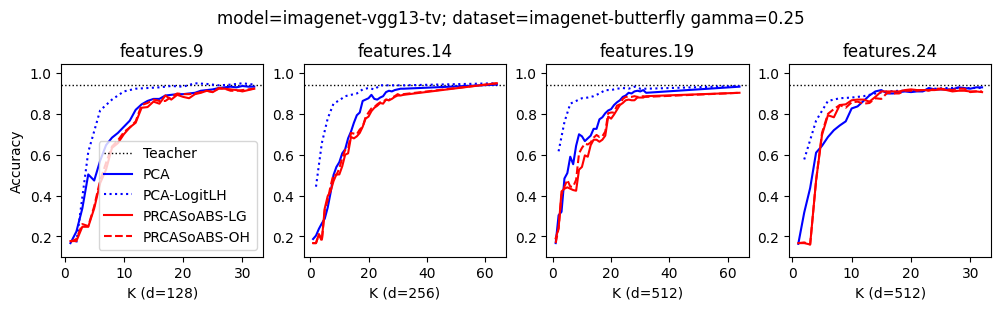

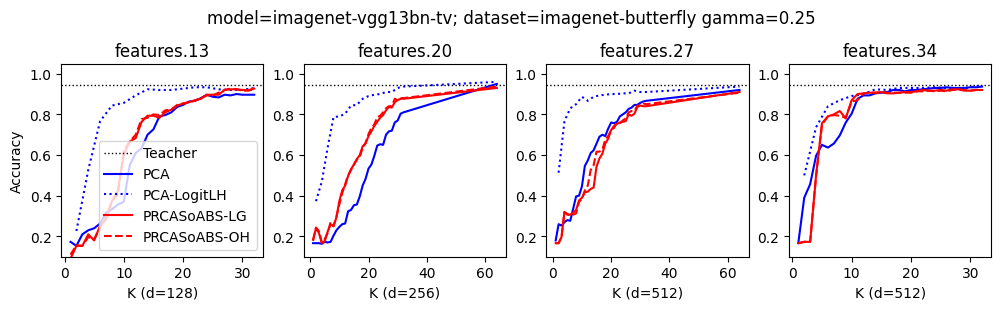

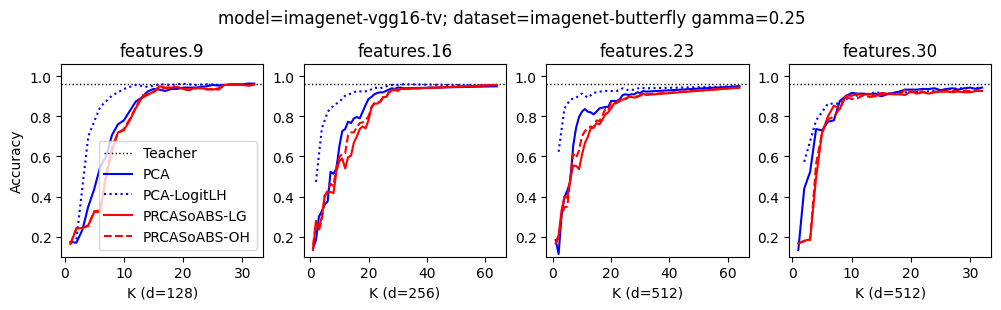

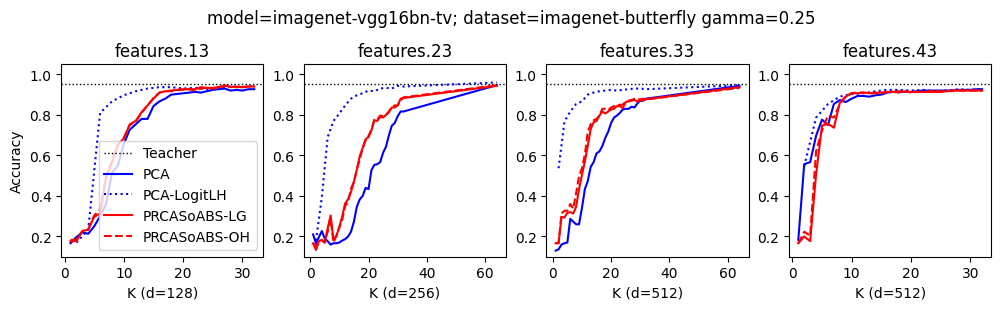

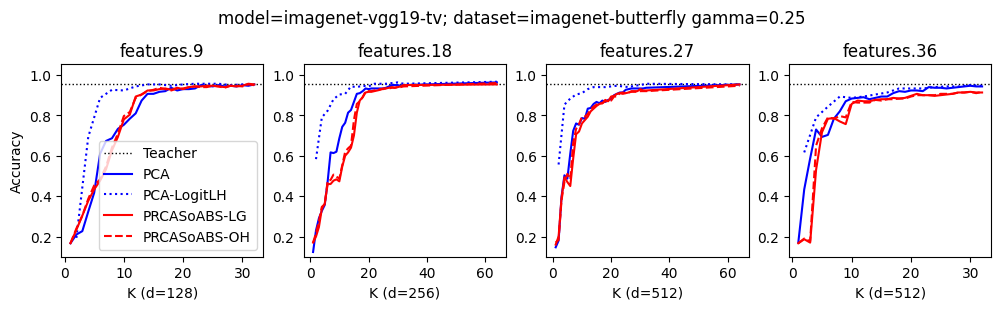

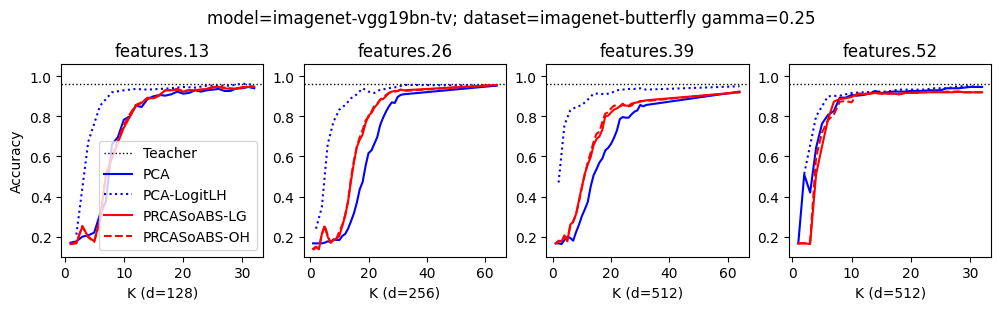

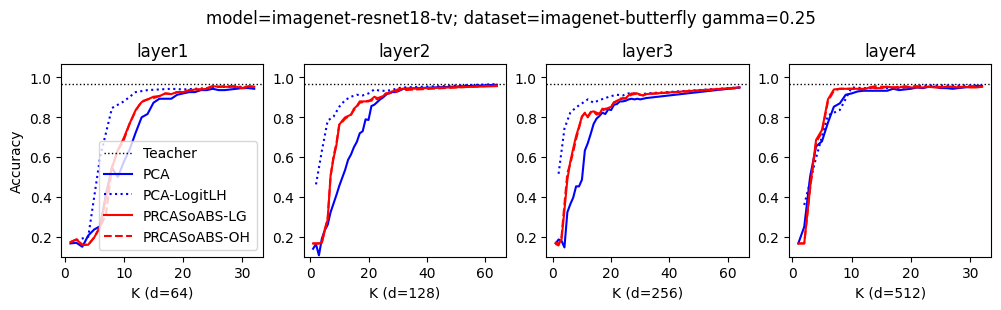

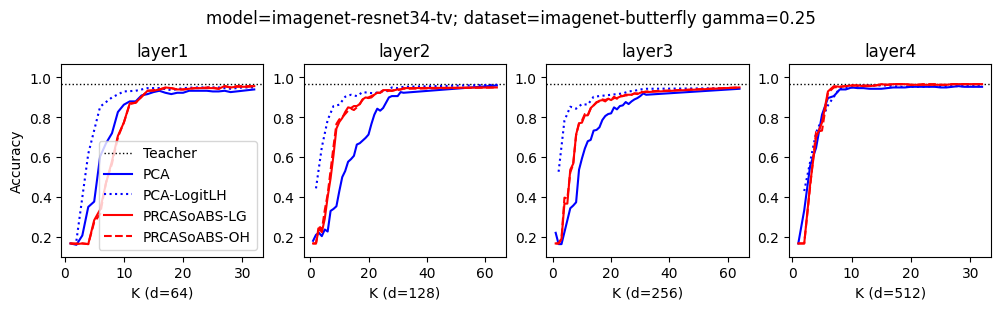

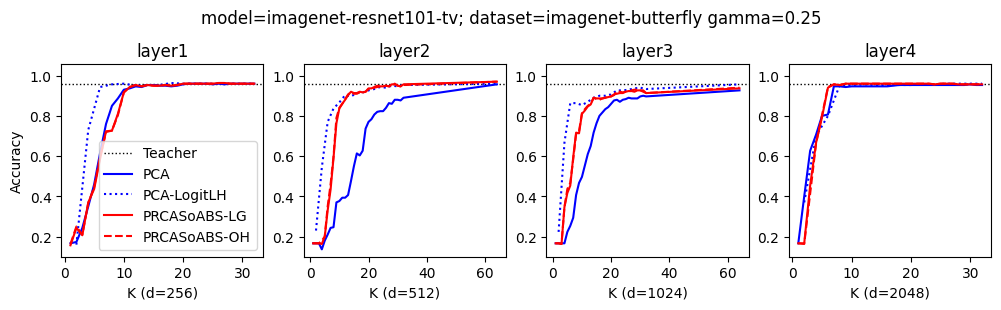

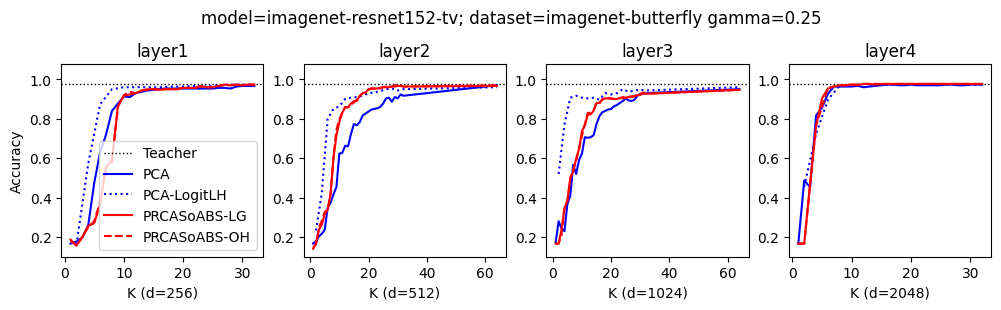

In [52]:
for arch in arr_archs:
    viz(
        dataset="imagenet-butterfly",
        model=arch,
        arr_max_k=[32, 64, 64, 32],
    )

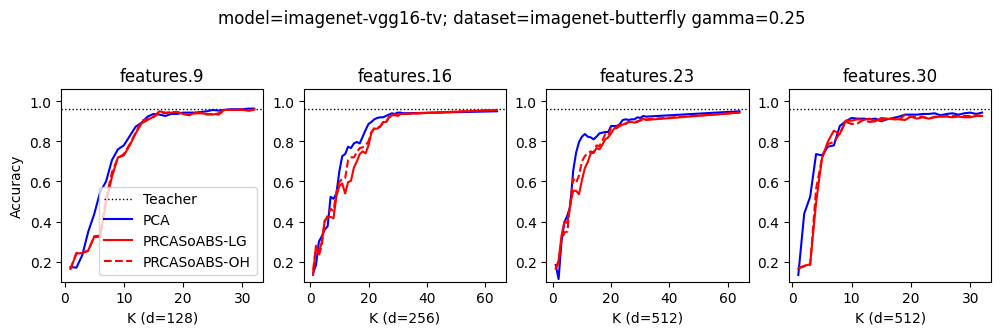

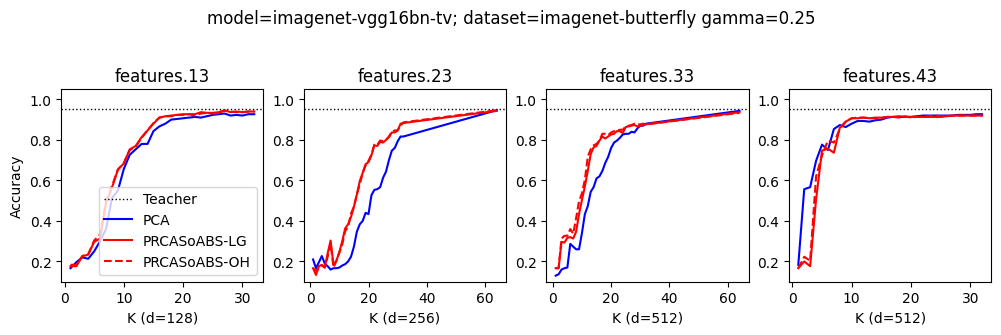

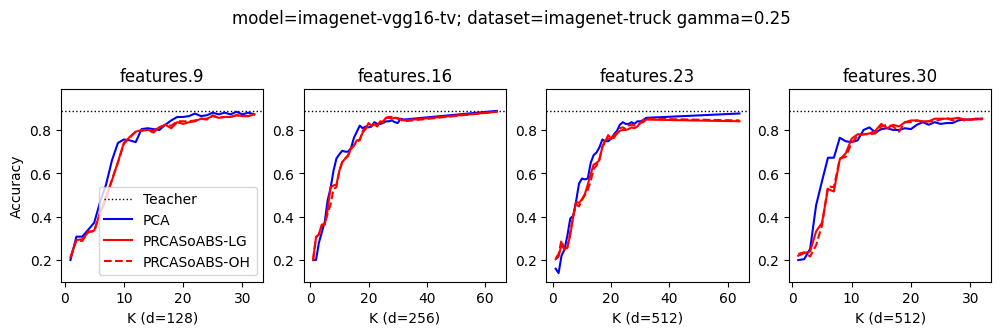

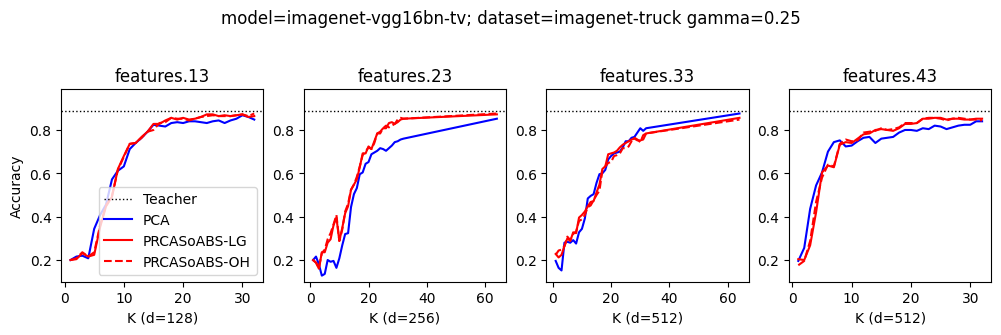

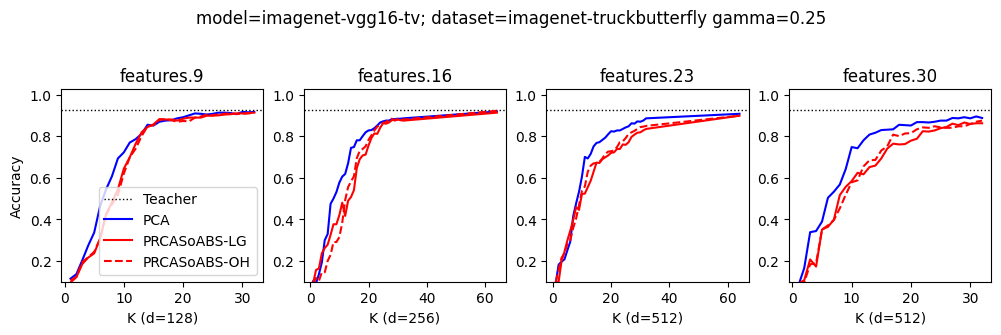

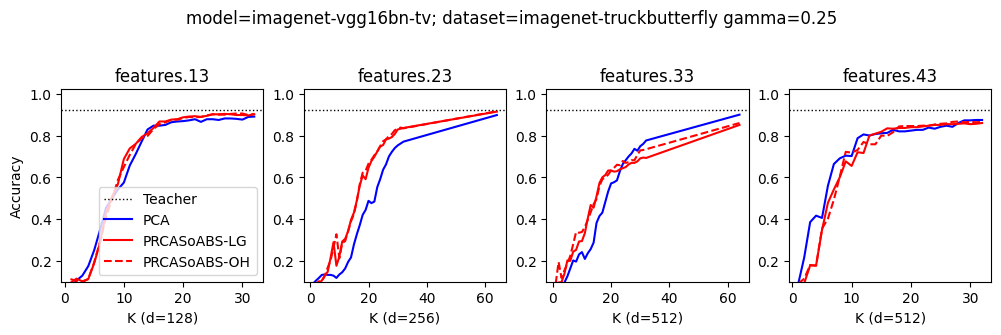

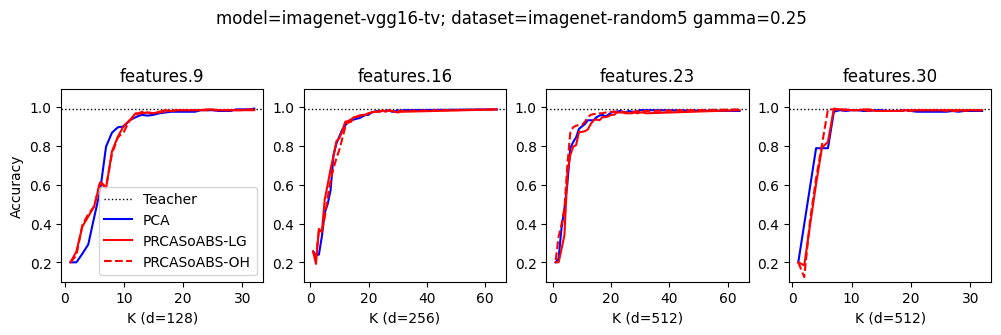

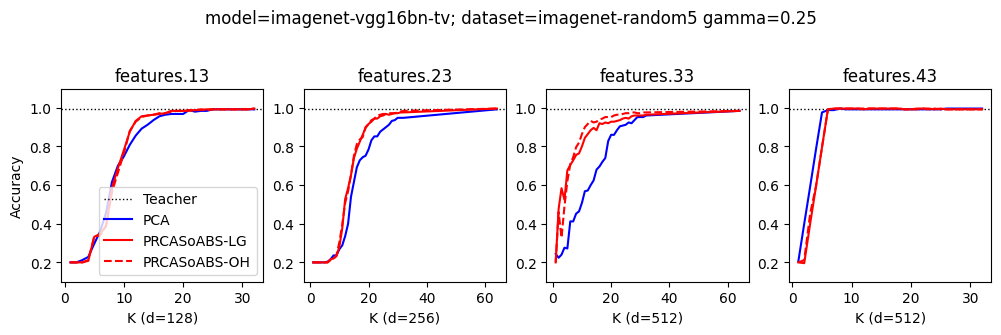

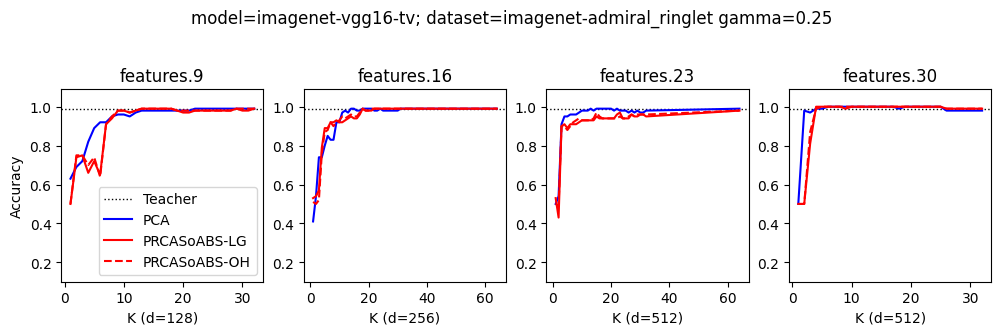

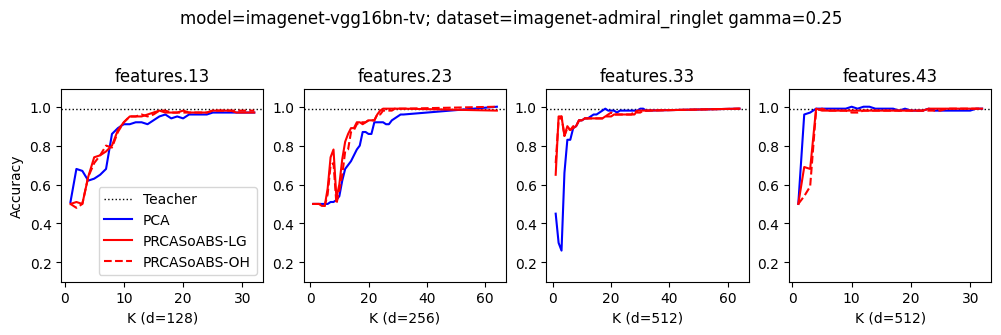

In [35]:

for dataset in [
    "imagenet-butterfly",
    "imagenet-truck",
    "imagenet-truckbutterfly",
    "imagenet-random5",
    "imagenet-admiral_ringlet"
]:
    for arch in [
    "imagenet-vgg16-tv",
    "imagenet-vgg16bn-tv"
#         "imagenet-resnet18-tv",
#         "imagenet-resnet34-tv",
#         "imagenet-resnet50-tv",
#         "imagenet-resnet101-tv",
#         "imagenet-resnet152-tv",
    ]:
        viz(
            dataset=dataset,
            model=arch,
#             arr_basis_names=["prcasortabs"],
            arr_max_k=[32, 64, 64, 32],
#             arr_logit_mods=["winninglogit"]
            arr_basis_names=[
       "pca:winninglogit",
       "prcasortabs:winninglogit",
       "prcasortabs:winningonehot", 
#        "prcaopt:winninglogit",
    ],
        )
